## PDE-Constrained optimization for coating design using eigenfunction basis expansion

In [22]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
import diffrax as dfx
import diffrax as diffrax
from PIL import Image
import numpy as np
from pde_opt.numerics.domains import Domain
from pde_opt.numerics.shapes import Shape,SpatialHeterogeneity
# from pde_opt.numerics.equations.allen_cahn import AllenCahn2DSmoothedBoundaryButlerVolmerConstantCurrent
from pde_opt.numerics.equations.allen_cahn import AllenCahn2DSBM_BV_CC
from pde_opt.pde_model import PDEModel
from pde_opt.numerics.solvers import ROCK2JAX
import optimistix as optx   # pip install optimistix
import equinox as eqx
from pde_opt.numerics.utils.initialization_utils import gen_c0

In [23]:
img = Image.open('../100lfp_binary.png').convert('L')
img_array = np.array(img)

# Threshold back to binary
binary = (img_array > 128).astype(np.float32)
binary_mask = jnp.array(binary)


In [24]:
shape = Shape(
    binary=jnp.array(binary_mask),
    dx=(1.0, 1.0),
    smooth_epsilon=3.0,
    smooth_curvature=0.008,
    smooth_dt=0.01,
    smooth_tf=100.0,
)

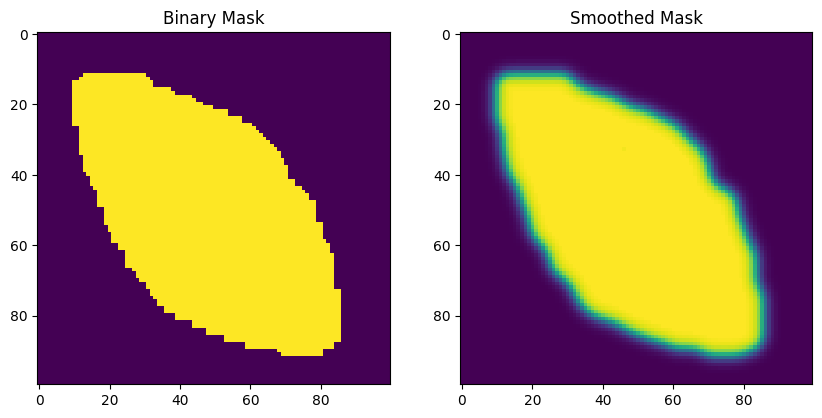

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(shape.binary)
axs[0].set_title("Binary Mask")
axs[1].imshow(shape.smooth)
axs[1].set_title("Smoothed Mask")
plt.show()

In [26]:
Nx, Ny = binary_mask.shape
pixel_length_rat = 50e-9
Lx=Nx*pixel_length_rat
Ly = Ny*pixel_length_rat
# Lx = 0.01 * Nx
# Ly = 0.01 * Ny

domain = Domain(
    (Nx, Ny), ((-Lx / 2, Lx / 2), (-Ly / 2, Ly / 2)), "dimensionless", shape
)

In [27]:
kappa = 0.002 #dimensionless
c_max = 2.29e4 #mol/m^3
F = 9.64853321233100184e4 #C⋅mol−1.
k0 = (1e-2 / F) #mol/(m^2 s)
H = 150e-9 #m
C_rate = 1e-2; #1/hr
kappa = 3.1314026858813996e13 #eV/m

In [28]:
kB = 8.617333262145e-5; #Boltzmann Constant [eV/K]
T=298.15; #Temperature [K]
omega = 0.11484582867125136; #eV
omega_tilde = omega / (kB * T)
f=lambda c: c * jnp.log(c) + (1.0 - c) * jnp.log(1.0 - c) + omega_tilde * c * (1.0 - c) + 0.059
mu=lambda c: jnp.log(c / (1.0 - c)) + omega_tilde * (1.0 - 2.0 * c)
j0 = lambda c: jnp.sqrt(c)*(1.0 - c)

In [29]:
# ----------------------------
# 0) Build mean-constrained evaluator and PDE instance
# ----------------------------
Nb = 100
sh = SpatialHeterogeneity.from_shape(shape=domain.geometry, n_basis=Nb, prior_fn=jnp.exp)
sh.build_mean_constrained(mask_type="binary")
k_eval_mc = sh.make_mean_constrained_evaluator(apply_mask=False)

theta0 = jnp.zeros((sh.mean_constrained_U.shape[1],))

eq = AllenCahn2DSBM_BV_CC(
    domain=domain, kappa=kappa, f=f, mu=mu, j0=j0,
    k0=k0, H=H, Cmax=c_max, Crate=C_rate,
    use_prefactor=True, mean_constrained=True,
    k_eval=None, k_eval_mc=k_eval_mc, theta=theta0,
)

shape = domain.geometry
psi_edge_inner = shape.get_mask_edge(connectivity=8, side="inner")
nucsite = jnp.where(psi_edge_inner, 0.2, 0.0)
key = random.PRNGKey(0)
u0_edge = gen_c0(shape, key, noise_fac=0.0, nucsite=nucsite)

t_start = 0.0
t_final_guess = eq.tf_tilde_est
dt0 =(eq.tf_tilde_est - t_start) / 100.0
def make_soc_event(eqmodel, *, threshold: float = 0.999):
    def cond_fn(t, y, args, **kwargs):
        return eqmodel.get_SOC(y) > threshold
    return dfx.Event(cond_fn)

event = make_soc_event(eq, threshold=0.999)
solver = ROCK2JAX()


In [30]:
warm_term = dfx.ODETerm(lambda t, y, args: eq.rhs(y, t))
warm_sol = dfx.diffeqsolve(
    warm_term, solver,
    t0=t_start, t1=t_final_guess, dt0=dt0, y0=u0_edge,
    stepsize_controller=dfx.PIDController(rtol=1e-4, atol=1e-6)
    , max_steps=50_000, event=event,
)
t_final_bound = warm_sol.ts[-1]

In [31]:
# Fixed time grid for optimization runs (no event)
Nsave = 128
ts_fixed = jnp.linspace(t_start, t_final_bound, Nsave)

# ----------------------------
# 3) Forward solve on fixed horizon (no event), pass k_field via args
# ----------------------------
rhs_with_k = eq.rhs_with_k_fn           # jitted function: (y, t, k_field) -> dy/dt
fixed_ode   = dfx.ODETerm(lambda t, y, k_field: rhs_with_k(y, t, k_field))
controller  = dfx.PIDController(rtol=1e-4, atol=1e-6)

def forward_fixed(y0, ts, k_field):
    dt0 = (ts[-1] - ts[0]) / 100
    return dfx.diffeqsolve(
        fixed_ode, solver,
        t0=ts[0], t1=ts[-1], dt0=dt0, y0=y0,
        args=k_field,
        stepsize_controller=controller,
        saveat=dfx.SaveAt(ts=ts),
        max_steps=50_000, event=None,
    )
forward_fixed_jit = eqx.filter_jit(forward_fixed)

# -------- UC pieces (psi-weighted) --------
def _uc_from_ys(ys, psi):
    """
    ys:  (T, Nx, Ny)
    psi: (Nx, Ny) weighting field (domain.geometry.smooth or .binary)
    """
    w = jnp.asarray(psi)
    A = jnp.sum(w)  # dxdy cancels, so we can omit it

    # mean concentration per time
    cbar_t = jnp.sum(ys * w[None, ...], axis=(1, 2)) / A  # (T,)

    # variance per time
    diffs = ys - cbar_t[:, None, None]
    v_t = jnp.sum((diffs**2) * w[None, ...], axis=(1, 2)) / A  # (T,)

    # UC = 1 - sum_i sqrt(v_i * cbar_i (1-cbar_i)) / sum_i cbar_i (1-cbar_i)
    eps = 1e-12
    cterm = jnp.clip(cbar_t * (1.0 - cbar_t), 0.0, 1.0)  # safety
    numer = jnp.sum(jnp.sqrt(jnp.maximum(v_t, 0.0) * cterm))
    denom = jnp.sum(cterm) + eps
    UC = 1.0 - numer / denom
    return UC

# -------- Optimistix objective: minimize (1 - UC) --------
# args will be (y0, ts_fixed, psi)
def uc_objective(theta, args):
    y0, ts, psi = args
    k_field = k_eval_mc(theta)                 # mean-constrained k(x,y)
    sol = forward_fixed(y0, ts, k_field)       # fixed-horizon solve (no event)
    UC = _uc_from_ys(sol.ys, psi)
    return 1.0 - UC                            # minimize 1-UC  <=> maximize UC


# Choose psi for quadrature: smooth (recommended) or binary
psi = domain.geometry.smooth  # or: domain.geometry.binary


In [32]:
# ---- Run BFGS on theta ----
solver_bfgs = optx.BFGS(
    rtol=1e-4, atol=1e-6,
    verbose=frozenset({"step","accepted","loss","step_size"}),
)
res_uc = optx.minimise(
    uc_objective,
    solver_bfgs,
    theta0,
    args=(u0_edge, ts_fixed, psi),   # arrays-only args (no eq/domain objects)
    max_steps=200,
    throw=False,
)

theta_star_uc = res_uc.value
print("BFGS status:", res_uc.state)

# ---------- Report UC (init vs optimized) ----------
# compute baseline and optimized UC on the SAME fixed horizon
sol_init = forward_fixed(u0_edge, ts_fixed, k_eval_mc(theta0))
sol_star = forward_fixed(u0_edge, ts_fixed, k_eval_mc(theta_star_uc))

UC_init = float(_uc_from_ys(sol_init.ys, psi))
UC_star = float(_uc_from_ys(sol_star.ys, psi))
print(f"UC initial:   {UC_init:.6f}")
print(f"UC optimized: {UC_star:.6f}")

Loss on this step: 0.4242380716451033, Loss on the last accepted step: 0.0, Step size: 1.0
Loss on this step: 0.40553664372150633, Loss on the last accepted step: 0.4242380716451033, Step size: 1.0
Loss on this step: 0.36930012235203313, Loss on the last accepted step: 0.40553664372150633, Step size: 1.0
Loss on this step: 0.4303581333863704, Loss on the last accepted step: 0.36930012235203313, Step size: 0.5
Loss on this step: 0.3901240278545035, Loss on the last accepted step: 0.36930012235203313, Step size: 0.25
Loss on this step: 0.36120830791364444, Loss on the last accepted step: 0.36930012235203313, Step size: 1.0
Loss on this step: 0.42553592939682994, Loss on the last accepted step: 0.36120830791364444, Step size: 0.5
Loss on this step: 0.4038633749993883, Loss on the last accepted step: 0.36120830791364444, Step size: 0.25
Loss on this step: 0.39334107069325874, Loss on the last accepted step: 0.36120830791364444, Step size: 0.125
Loss on this step: 0.37833281743694, Loss on 

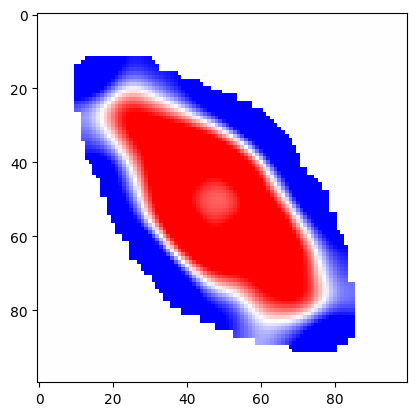

In [33]:
plt.imshow(np.log(k_eval_mc(theta_star_uc)),cmap='bwr',vmin=-0.01,vmax=0.01)

In [34]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.gridspec import GridSpec
from IPython.display import HTML

# --- 1) Build k-fields and solve both trajectories (no event) ---
k0_field     = k_eval_mc(theta0)
kstar_field  = k_eval_mc(theta_star_uc)
sol_init     = forward_fixed(u0_edge, ts_fixed, k0_field)
sol_star     = forward_fixed(u0_edge, ts_fixed, kstar_field)

# --- 2) Prep data ---
mask   = domain.geometry.binary
psi    = domain.geometry.smooth   # use .binary if you prefer
extent = [domain.box[0][0], domain.box[0][1],
          domain.box[1][0], domain.box[1][1]]

ys0   = np.array(sol_init.ys)      # (T, Nx, Ny)
ysopt = np.array(sol_star.ys)
ts    = np.array(sol_init.ts)

if ys0.shape[0] != ysopt.shape[0] or not np.allclose(ts, np.array(sol_star.ts)):
    raise ValueError("sol_init and sol_star must share the same time grid.")

T = ys0.shape[0]
mask_np = np.array(mask, dtype=ys0.dtype)
psi_np  = np.array(psi, dtype=ys0.dtype)

masked0   = ys0   * mask_np
maskedopt = ysopt * mask_np

# --- 3) Uniformity Coefficient helper ---
def uniformity_coefficient_from_ys(ys, psi_arr):
    w = psi_arr
    A = np.sum(w)
    cbar = np.sum(ys * w[None, ...], axis=(1, 2)) / A
    diffs = ys - cbar[:, None, None]
    v_t = np.sum((diffs**2) * w[None, ...], axis=(1, 2)) / A
    cterm = np.clip(cbar * (1.0 - cbar), 0.0, 1.0)
    numer = np.sum(np.sqrt(np.maximum(v_t, 0.0) * cterm))
    denom = np.sum(cterm) + 1e-12
    return float(1.0 - numer / denom)

UC_init = uniformity_coefficient_from_ys(ys0,  psi_np)
UC_star = uniformity_coefficient_from_ys(ysopt, psi_np)

# --- 4) Figure with GridSpec (colorbar column) ---
fig = plt.figure(figsize=(10.5, 4.6), constrained_layout=True)
gs  = GridSpec(nrows=1, ncols=3, width_ratios=[1, 1, 0.06], figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])  # colorbar column

# fixed color scale
vmin, vmax = 0.0, 1.0

# initial frame artists
im0 = ax0.imshow(masked0[0],   animated=True, vmin=vmin, vmax=vmax, extent=extent)
im1 = ax1.imshow(maskedopt[0], animated=True, vmin=vmin, vmax=vmax, extent=extent)

ax0.set_title("Baseline (θ₀)")
ax1.set_title("Optimized (θ*)")
for ax in (ax0, ax1):
    ax.set_xlabel("")     # hide labels
    ax.set_ylabel("")
    ax.set_xticks([])     # hide ticks
    ax.set_yticks([])
    ax.set_frame_on(True)

# UC badges (static, white, top-right)
ax0.text(0.98, 0.02, f"UC={UC_init:.4f}", transform=ax0.transAxes,
         ha="right", va="bottom", color="white", fontsize=11, fontweight="bold",
         bbox=dict(facecolor=(0,0,0,0.35), edgecolor='none', pad=3))
ax1.text(0.98, 0.02, f"UC={UC_star:.4f}", transform=ax1.transAxes,
         ha="right", va="bottom", color="white", fontsize=11, fontweight="bold",
         bbox=dict(facecolor=(0,0,0,0.35), edgecolor='none', pad=3))

# bottom status text
def avg_over_mask(arr):
    return float((arr * mask_np).sum() / mask_np.sum())

txt0 = ax0.text(0.01, -0.06, "", transform=ax0.transAxes, ha="left", va="top", animated=True)
txt1 = ax1.text(0.01, -0.06, "", transform=ax1.transAxes, ha="left", va="top", animated=True)

# colorbar
cb = fig.colorbar(im1, cax=cax)
cb.set_label("Concentration")

# --- 5) Build frames (full time resolution) ---
ims = []
for i in range(T):
    im0_i = ax0.imshow(masked0[i],   animated=True, vmin=vmin, vmax=vmax, extent=extent)
    im1_i = ax1.imshow(maskedopt[i], animated=True, vmin=vmin, vmax=vmax, extent=extent)

    t    = float(ts[i])
    avg0 = avg_over_mask(masked0[i])
    avg1 = avg_over_mask(maskedopt[i])

    txt0_i = ax0.text(0.01, -0.06, f"t={t:.6f}, avg={avg0:.6f}",
                      transform=ax0.transAxes, ha="left", va="top", animated=True)
    txt1_i = ax1.text(0.01, -0.06, f"t={t:.6f}, avg={avg1:.6f}",
                      transform=ax1.transAxes, ha="left", va="top", animated=True)

    ims.append([im0_i, im1_i, txt0_i, txt1_i])

ani = animation.ArtistAnimation(fig, ims, interval=35, blit=True, repeat_delay=800)

plt.close(fig)
HTML(ani.to_jshtml())
